<a href="https://colab.research.google.com/github/Kashyyaap/AI-ML_Internship/blob/main/DAY_3(part_a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

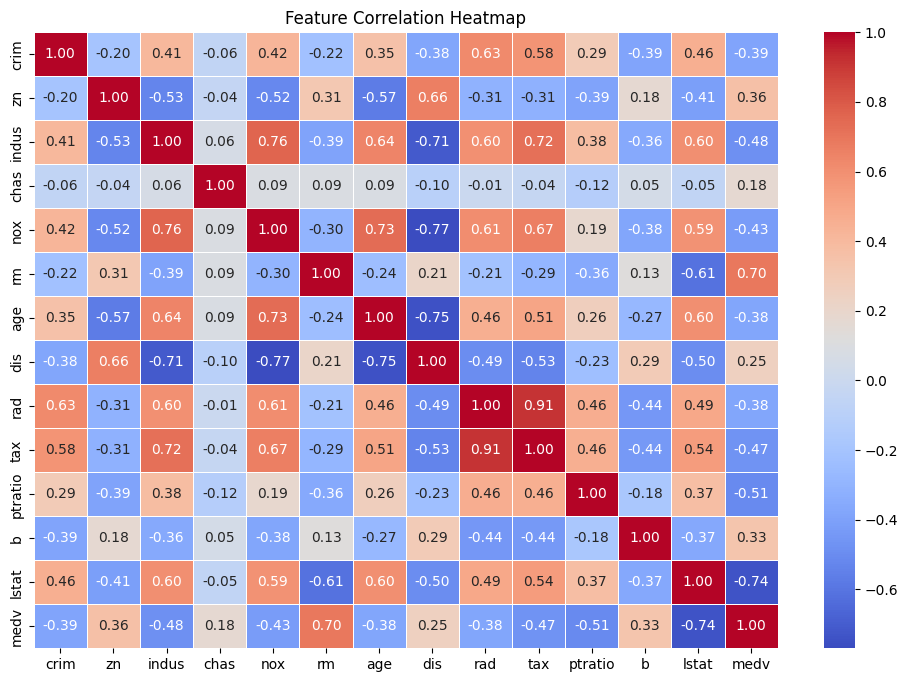

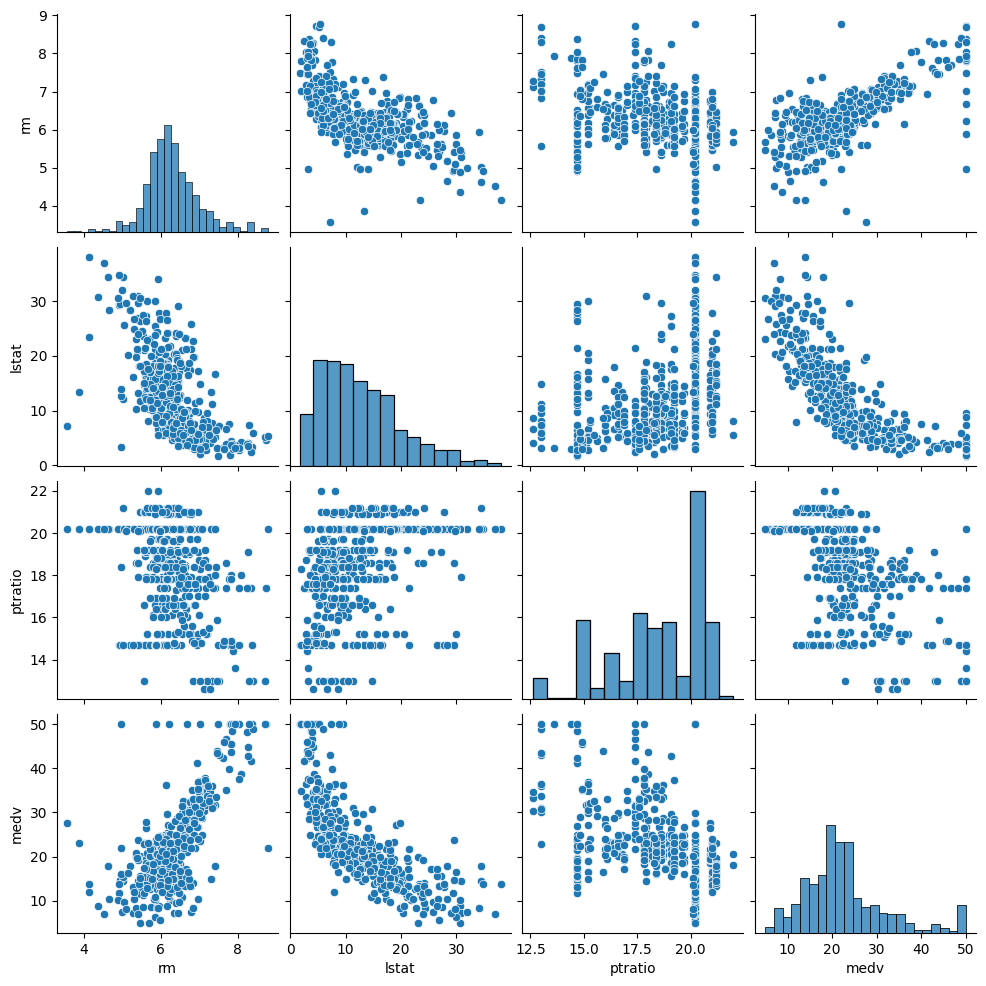

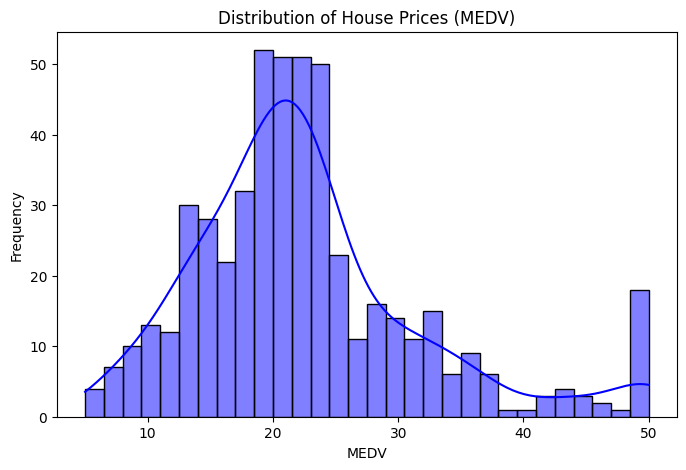

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/boston.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score


X = df.drop(columns=["medv"])
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6687594935356326


In [ ]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 4.928602182665332


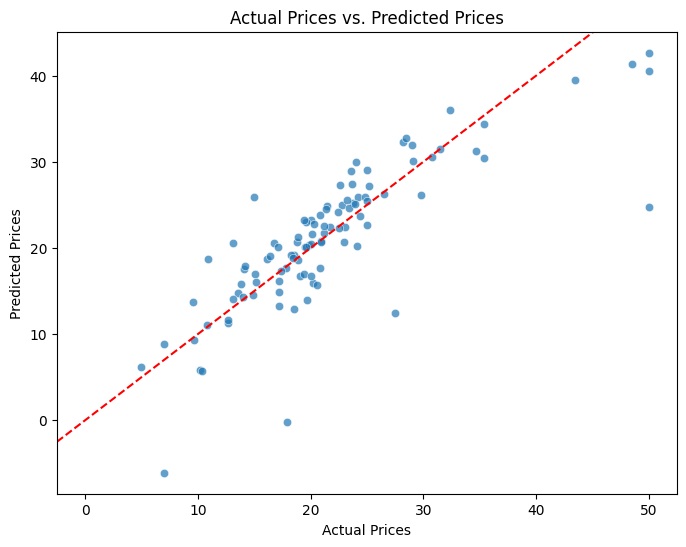

In [ ]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

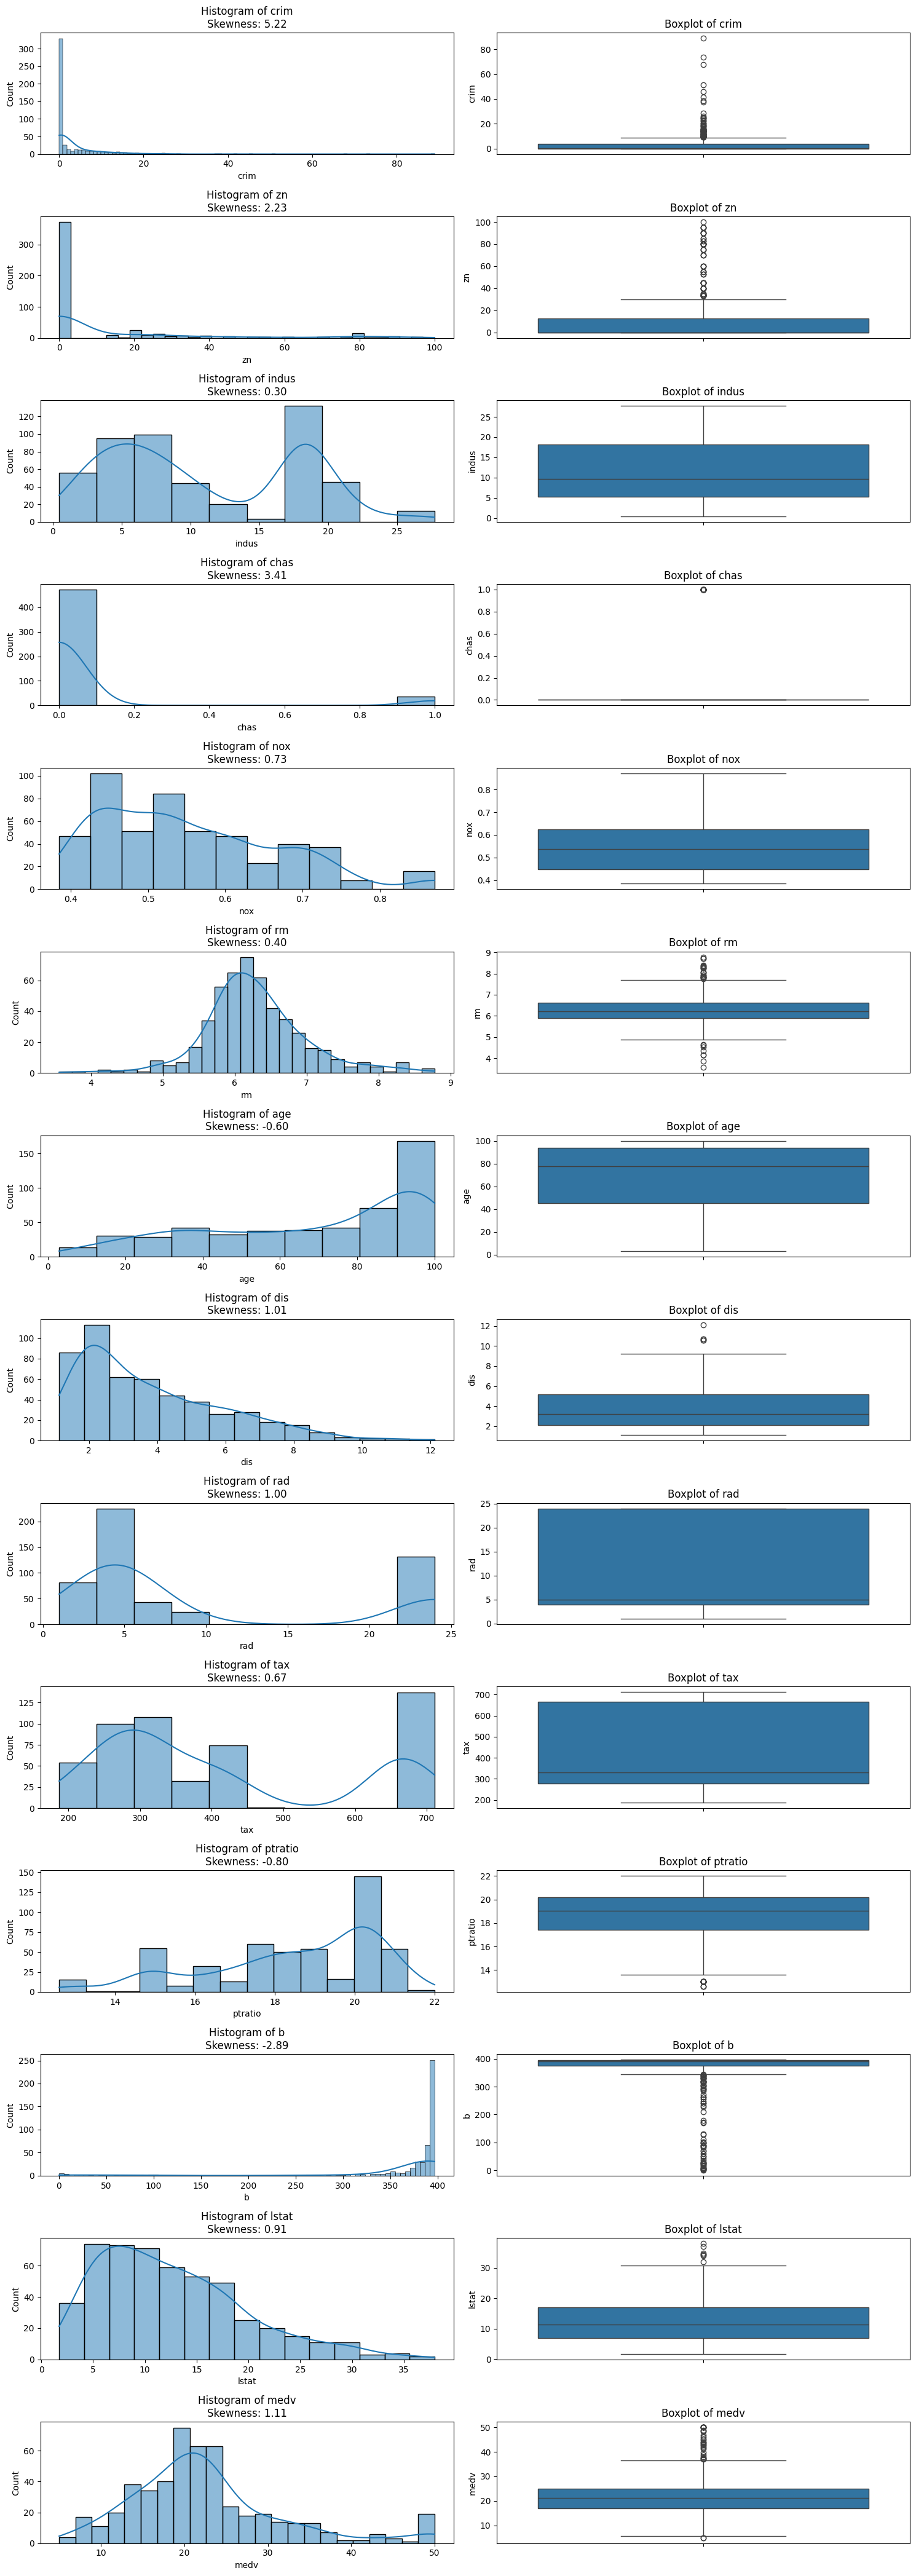

In [ ]:
from scipy.stats import skew
skewness = df.skew()

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols * 3))

for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index

print("Highly Skewed Columns:\n")
print(highly_skewed)

print("\nNegatively Skewed Columns:")
print(negatively_skewed)


Highly Skewed Columns:

Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')

Negatively Skewed Columns:
Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [ ]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="yeo-johnson")
df[negatively_skewed] = pt.fit_transform(df[negatively_skewed])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score


X = df.drop(columns=["medv"])
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7554677765706578


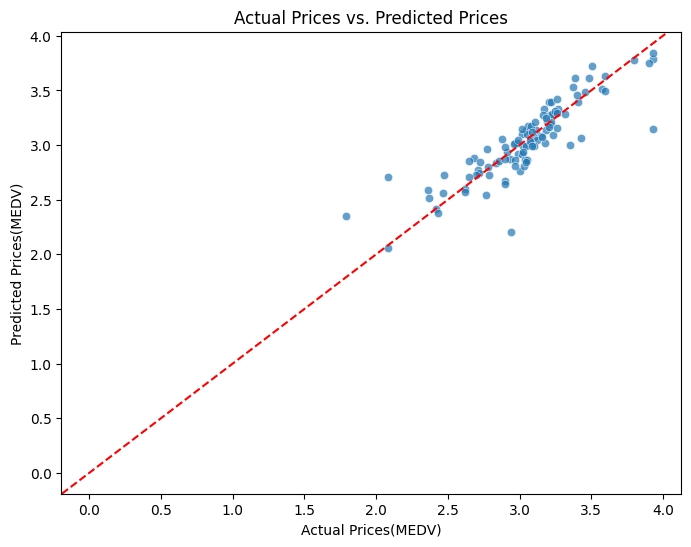

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.8409499057793878
RMSE: 0.14852560288069508


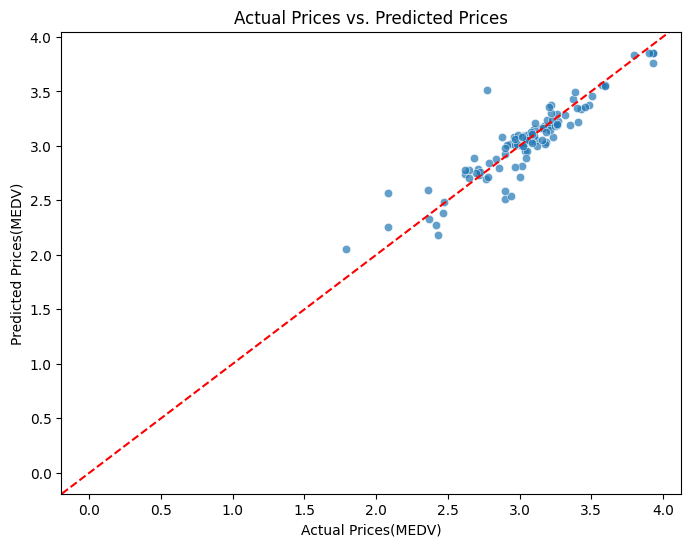

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices(MEDV)")
plt.ylabel("Predicted Prices(MEDV)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()